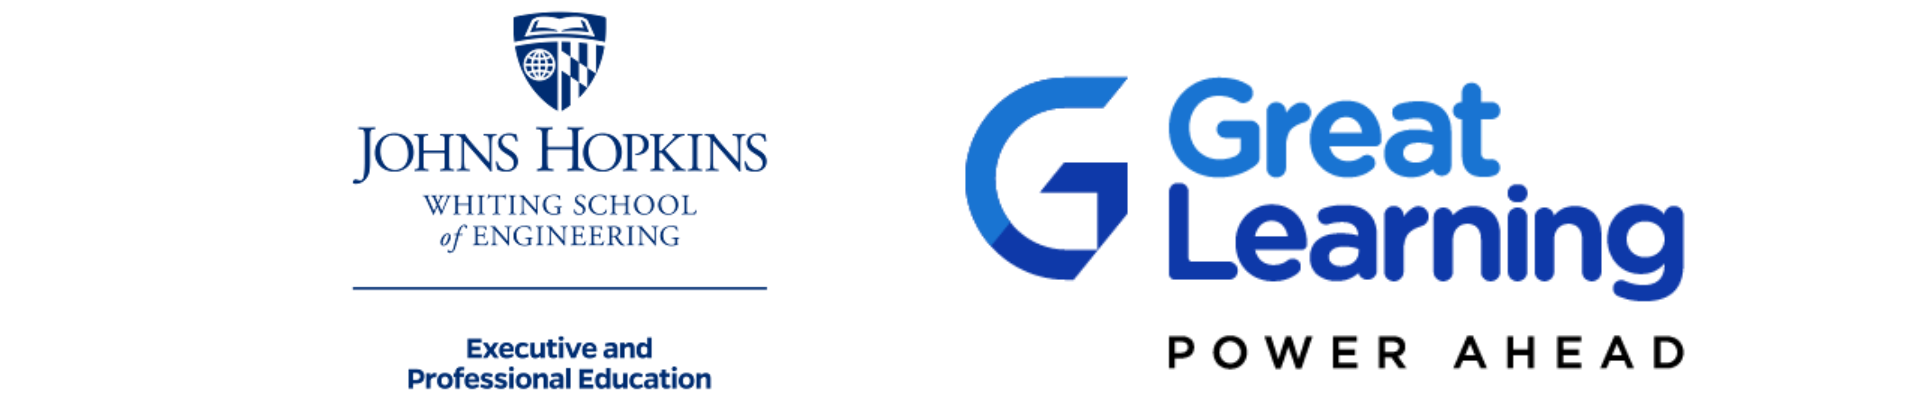

# Evaluating GenAI Workflows & Prompt Optimization

## Learning Objectives:

- Why is Evaluation important?
- Understand how variance in LLM parameters changes the output responses
- Recap of LLM workflow lifecycle
- Prompt Versioning
- Prompt Evaluation Strategies for NLP Tasks
    - Understanding Prompt Stability (Self-Consistency)
    - Gold Example Dataset Curation for Evaluation
- DSPy for Prompt Optimization and Evaluation (apply programmatic prompt optimization techniques)

## Notebook Structure


| Lecture | Notebook Section | Core Question |
|---------|------------------|---------------|
| 1 — Prompting is inherently brittle | Section 1: Observing Variability | Why isn't "sounds good" enough? |
| 2 — LLM workflow lifecycle | Section 2: Workflow Lifecycle | How does prompt development fit into a disciplined process? |
| 3 — Task-specific evaluation | Section 3: Task-Specific Evaluation | What does "good" mean for different tasks? |
| 4 — Stability & output evaluation | Section 4: Stability & Output Evaluation | How do we measure reliability? |
| 5 — Gold datasets & human evaluation | Section 5: Gold Datasets & Human Evaluation | Where does ground truth come from? |
| 6 — DSPy & prompt versioning| Section 6: Structured Optimization & Evaluation | How do we systematize improvement? |


The central theme of this notebook is the following:


> **"A prompt is not good because it sounds good; it is good because it performs reliably on a defined task under a defined evaluation protocol."**

# Installing and importing the libraries

In [75]:
!uv pip install openai datasets dspy-ai optuna scikit-learn pandas tqdm numpy tiktoken langchain langchain-openai langchain-chroma chromadb --quiet

In [76]:
# Importing the required libraries
import os, json, re, hashlib, copy, time, uuid, textwrap, warnings
import datetime
from collections import Counter
from pathlib import Path
import seaborn as sns
from datetime import datetime
from collections import Counter, defaultdict
from typing import Any, List, Dict, Optional, Tuple, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from openai import OpenAI
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Langchain imports
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser
warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 120)

In [77]:
import json
import os
from openai import OpenAI

with open("config.json", "r") as f:
    config = json.load(f)

api_key = config["OPENAI_API_KEY"]
api_base = config["OPENAI_BASE_URL"]

os.environ["OPENAI_API_KEY"] = api_key
os.environ["OPENAI_API_BASE"] = api_base

client = OpenAI(
    api_key=api_key,
    base_url=api_base,
)

In [78]:
MODEL = "gpt-4o-mini"
# MODEL = "gpt-5-mini"

In [118]:
# Function to call OpenAI LLM
def llm_call(prompt: str, system: str = "You are a helpful assistant.",
             model: str = MODEL, temperature: float = 1.0, top_p: float = 1.0,
             max_tokens: int = 1024, n: int = 1, parse_json: bool = False) -> Union[Any, list[Any]]:

    """
    Make an LLM call and return a list of response texts (one per n).
    If parse_json is True, enforces JSON format and returns parsed Python dictionaries.

    Args:
        prompt (str): The user's input prompt for the LLM.
        system (str): The system prompt, defining the LLM's role or behavior. Defaults to 'You are a helpful assistant.'.
        model (str): The specific LLM model to use (e.g., 'gpt-4o-mini'). Defaults to MODEL.
        temperature (float): Controls the randomness of the output. Higher values mean more random. Defaults to 1.0.
        top_p (float): Controls the diversity of the output by nucleus sampling. Defaults to 1.0.
        max_tokens (int): The maximum number of tokens to generate in the completion. Defaults to 1024.
        n (int): The number of chat completion choices to generate. Defaults to 1.
        parse_json (bool): If True, attempts to parse the LLM's output as JSON. Defaults to False.

    Returns:
        Union[Any, list[Any]]: The LLM's response(s). If n=1 and parse_json=False, returns a string.
                                 If n>1 and parse_json=False, returns a list of strings.
                                 If parse_json=True, returns a parsed JSON object (dict/list) or a list of such objects.
    """

    # OpenAI requires the prompt to explicitly mention "JSON" when using json_object mode.
    # This ensures the model is aware of the desired output format.
    if parse_json and "json" not in system.lower() and "json" not in prompt.lower():
        system += " You must respond in JSON format."

    # Prepare arguments for the OpenAI API call
    api_kwargs = {
        "model": model, # Specify the LLM model to use
        "messages":[
            {"role": "system", "content": system},
            {"role": "user", "content": prompt},
        ],
        "temperature": temperature,
        "top_p": top_p,
        "max_completion_tokens": max_tokens,
        "n": n,
    }

    # If JSON parsing is requested, configure the API to enforce JSON response format.
    if parse_json:
        api_kwargs["response_format"] = {"type": "json_object"}

    # Execute the API call to OpenAI's chat completions endpoint
    response = client.chat.completions.create(**api_kwargs)

    # Process and return the results based on 'n' and 'parse_json' settings
    results = []
    for choice in response.choices:
        content = choice.message.content

        # If JSON parsing is enabled and content is not empty
        if parse_json and content:
            try:
                results.append(json.loads(content))
            except json.JSONDecodeError:
                results.append({"error": "Failed to parse JSON", "raw_content": content})
        else:
            results.append(content)

    # If only one completion was requested (n=1), return the first result directly.
    # Otherwise, return the list of all results.
    if n == 1:
        if results:
            return results[0]
        else:
            return None
    else:
        return results

In [80]:
# # Testing the llm_call function
# text_response = llm_call(prompt="Name two planets in our solar system.", parse_json=False)
# print("Standard Output:")
# print(text_response)
# print(type(text_response))

# json_response = llm_call(prompt="Name two planets in our solar system. Output keys should be 'planet_1' and 'planet_2'", parse_json=True)
# print("\nJSON Output:")
# print(json_response)
# print(type(json_response))

## Use Case: Docs-Grounded Developer Assistant

Every section in this notebook revolves around a single, coherent scenario — a **developer assistant** that operates over project documentation. This assistant must:

- **Answer questions** from documentation (Q&A)
- **Summarize** technical material
- **Classify** incoming issues
- **Generate code** grounded in source docs


We use **FastAPI documentation** as our corpus — a real, widely-used Python web framework with rich, well-structured docs covering routing, parameters, request bodies, error handling, file uploads, and dependency injection.

---

# Section 1 - Why Evaluation Matters

---
*Pre-requisite: Lecture 1 - Need for Evaluation & why Prompt Optimization Matters*

In this section you will:

1. Define a **documentation corpus** from FastAPI docs for our developer-assistant scenario.
2. Run the **same prompt multiple times** and observe how outputs vary.
3. Compare two prompts that *sound equally reasonable* but **perform differently**.
4. Reflect on why "sounds good" is an unreliable indicator of prompt quality.

---


In [81]:
# ── FastAPI documentation corpus ──────────────────────────────────────
# This corpus contains condensed excerpts from the official FastAPI documentation.
# In a real system this could be thousands of pages of API docs, tutorials, and guides.

CORPUS = {
    "first_steps": (
        "FastAPI is a modern, fast web framework for building APIs with Python. "
        "The simplest FastAPI file imports FastAPI, creates an app instance, and defines path operations "
        "using decorators like @app.get('/'). Path operations can be async def or normal def. "
        "Run the dev server with: fastapi dev main.py. The app is served at http://127.0.0.1:8000. "
        "Automatic interactive API docs are available at /docs (Swagger UI) and /redoc (ReDoc). "
        "FastAPI generates an OpenAPI schema at /openapi.json. "
        "The six-step recap: (1) Import FastAPI, (2) Create an app instance, "
        "(3) Create a path operation decorator, (4) Define the path operation function, "
        "(5) Return content (dict, list, str, int, Pydantic models are auto-converted to JSON), "
        "(6) Deploy. HTTP methods supported: POST, GET, PUT, DELETE, OPTIONS, HEAD, PATCH, TRACE. "
        "FastAPI inherits from Starlette, so all Starlette functionality is available. "
        "For production, use fastapi run instead of fastapi dev."
    ),
    "path_params": (
        "Path parameters are declared using Python format-string syntax in the route path, e.g. "
        "@app.get('/items/{item_id}'). The value is passed to the function argument matching the "
        "parameter name. Type annotations give you automatic data conversion (string from URL to "
        "Python int), data validation (invalid values return a clear JSON error with type, loc, msg, input), "
        "and auto-generated documentation. Validation is powered by Pydantic; types str, float, bool "
        "and complex types are all supported. Order matters: fixed paths like /users/me must be "
        "declared before parameterized paths like /users/{user_id}, otherwise the dynamic path matches first. "
        "You cannot redefine a path operation — the first match wins. Predefined values use Python Enum: "
        "create a subclass of str and Enum with class attributes as fixed values, then annotate the path "
        "parameter with that enum class. Path parameters containing paths use Starlette's path converter "
        "syntax {file_path:path} to match paths with slashes. A leading slash requires a double slash in the URL."
    ),
    "query_params": (
        "Query parameters are function parameters that are not part of the path. They appear after ? in the URL, "
        "separated by &. They are naturally strings from the URL but are auto-converted and validated when you "
        "declare Python types, e.g. skip: int = 0, limit: int = 10. Query parameters can have default values, "
        "making them optional — if you go to the URL without those parameters, defaults are used. "
        "Optional parameters use a default of None, e.g. q: str | None = None. FastAPI distinguishes path "
        "parameters from query parameters automatically by matching parameter names against the path. "
        "Bool type conversion: values like 1, True, true, on, yes (case-insensitive) become True; anything else "
        "becomes False. Multiple path and query parameters can be declared together; FastAPI detects each by name, "
        "and the declaration order in the function signature doesn't matter. Required query parameters are created "
        "by simply not providing a default value, e.g. needy: str. Omitting a required query parameter returns "
        "an error JSON with type 'missing' and msg 'Field required'. You can mix required, default-valued, and "
        "optional (None-defaulted) parameters in the same function. Enums work with query parameters the same way "
        "as with path parameters."
    ),
    "request_body": (
        "A request body is data sent by the client to your API; a response body is what the API sends back. "
        "Use POST, PUT, DELETE, or PATCH for sending bodies. GET with a body is undefined in the spec. "
        "To declare a request body, use Pydantic's BaseModel: from pydantic import BaseModel, create a class "
        "inheriting from BaseModel, and define attributes with Python type annotations. Attributes with default "
        "values are optional; those without defaults are required. Use None for purely optional fields. "
        "Declare the model as a function parameter with its type, and FastAPI will: read the request body as JSON, "
        "convert types, validate data (returning clear errors on invalid data), provide the parameter as the model "
        "instance with full editor support, and generate JSON Schema definitions included in the OpenAPI schema. "
        "Inside the function, access model attributes directly. Request body + path parameters: declare both; "
        "FastAPI takes path params from the path and Pydantic models from the body. Request body + path + query "
        "parameters: FastAPI recognizes each by rules: (1) if the parameter name matches a path variable, it's a "
        "path parameter; (2) if the parameter has a singular type (int, float, str, bool), it's a query parameter; "
        "(3) if the parameter type is a Pydantic model, it's a request body."
    ),
    "handling_errors": (
        "To return HTTP errors, use HTTPException from fastapi. Import it and raise it (don't return it) — "
        "e.g. raise HTTPException(status_code=404, detail='Item not found'). Because it's a Python exception, "
        "raising it from anywhere (including utility functions called by path operations) terminates the request "
        "immediately and sends the error response. The detail parameter accepts any JSON-convertible value "
        "(str, dict, list, etc.). Custom headers: pass a headers dict to HTTPException, e.g. for security "
        "scenarios like X-Error-Name. Custom exception handlers: use @app.exception_handler(SomeException) to "
        "register a handler for custom exceptions. The handler receives Request and the exception, and returns "
        "a Response. Override default exception handlers: FastAPI has default handlers for HTTPException and "
        "RequestValidationError. To override request validation errors, import RequestValidationError from "
        "fastapi.exceptions and use @app.exception_handler(RequestValidationError). To override the "
        "HTTPException handler, register for Starlette's HTTPException (import as "
        "from starlette.exceptions import HTTPException as StarletteHTTPException). FastAPI's HTTPException "
        "differs from Starlette's only in accepting any JSON-able detail. RequestValidationError has a body "
        "attribute containing the received invalid body, useful for debugging and logging."
    ),
    "request_files": (
        "File uploads require python-multipart installed (pip install python-multipart) because files are sent "
        "as form data. Import File and UploadFile from fastapi. Declare file parameters with File(): "
        "fileb: Annotated[bytes, File()] — FastAPI reads the entire file contents as bytes (stored in memory, "
        "suitable for small files). UploadFile is preferred for larger files: file: UploadFile. Advantages of "
        "UploadFile: doesn't require File() in the default value; uses a SpooledTemporaryFile (stored in memory "
        "up to a size limit, then spooled to disk); supports large files without exhausting memory. UploadFile "
        "attributes: filename (str, original name), content_type (str, MIME type), file (the SpooledTemporaryFile "
        "object). UploadFile async methods: write(data), read(size), seek(offset), close() — all must be awaited. "
        "In normal def path operations, access UploadFile.file directly for synchronous reads. Forms without files "
        "use application/x-www-form-urlencoded; forms with files use multipart/form-data. You cannot declare JSON "
        "Body fields alongside File/Form parameters in the same request — HTTP protocol limitation. Optional file "
        "upload: use None default (e.g. file: UploadFile | None = None). Multiple file uploads: declare a list "
        "of UploadFile (e.g. files: list[UploadFile])."
    ),
    "dependencies": (
        "FastAPI has a powerful Dependency Injection system. A dependency (dependable) is a function that can take "
        "all the same parameters a path operation function can (query params, etc.) and returns whatever you need. "
        "Declare it in a path operation using Depends(): e.g. commons: Annotated[dict, Depends(common_parameters)]. "
        "You pass the function reference (not called — no parentheses) to Depends(). On each request, FastAPI calls "
        "the dependency with correct parameters, gets the result, and injects it into the path operation function. "
        "Dependencies support async def and normal def interchangeably. Shared Annotated dependencies: store "
        "Annotated types in variables (type aliases) to reuse across multiple path operations without duplication, "
        "preserving type info for editors and mypy. Use cases for DI: shared logic, database connections, "
        "security/auth enforcement. No special registration is needed — just pass to Depends. Hierarchical "
        "dependencies: dependencies can themselves depend on other dependencies, forming a tree that FastAPI "
        "resolves automatically. Example hierarchy: current_user -> active_user -> admin_user and "
        "active_user -> paying_user, with different endpoints requiring different levels. All dependency "
        "declarations, validations, and requirements are integrated into the OpenAPI schema and shown in "
        "interactive docs. The DI system makes FastAPI compatible with relational/NoSQL databases, external "
        "packages/APIs, auth systems, monitoring, and more."
    ),
    "numeric_validations": (
        "Use Path from fastapi (with Annotated) to declare validations and metadata for path parameters, "
        "just like Query for query parameters. Import Annotated from typing and Path from fastapi. Example: "
        "item_id: Annotated[int, Path(title='The ID of the item to get')]. A path parameter is always required — "
        "even declaring None or a default doesn't change that. Without Annotated, Python complains if a parameter "
        "with a default precedes one without. Solutions: (1) reorder parameters (FastAPI detects by name, not order), "
        "(2) use * as the first function parameter to force keyword-only params, or (3) prefer Annotated which avoids "
        "the issue entirely. Numeric validations via Path/Query arguments: ge (greater than or equal), gt (greater than), "
        "le (less than or equal), lt (less than). Example: item_id: Annotated[int, Path(ge=1, le=1000)]. Float values "
        "work too; gt is especially useful for floats (e.g. gt=0 allows 0.5 but not 0.0). Query, Path, and similar "
        "classes share a common Param base class with the same validation/metadata parameters. What you import as "
        "Query/Path are functions that return instances of classes of the same name — this pattern avoids editor "
        "type-checking errors."
    ),
}

print(f"Corpus loaded: {len(CORPUS)} documents")
for doc_id in CORPUS:
    print(f"  * {doc_id}: {len(CORPUS[doc_id])} chars")


Corpus loaded: 8 documents
  * first_steps: 939 chars
  * path_params: 1035 chars
  * query_params: 1234 chars
  * request_body: 1288 chars
  * handling_errors: 1342 chars
  * request_files: 1274 chars
  * dependencies: 1463 chars
  * numeric_validations: 1180 chars


###  Understanding LLM behavior - Decoding Parameters

**How LLMs Generate Text**

At each step, the model produces a **probability distribution** over all tokens in its vocabulary. The decoding strategy determines which token is selected.

```
Token Probabilities (simplified):
  "Paris"    → 0.45
  "London"   → 0.20
  "Berlin"   → 0.15
  "Madrid"   → 0.10
  "Rome"     → 0.05
  "Tokyo"    → 0.03
  "Atlantis" → 0.02
```

### Temperature

**Temperature** controls the *sharpness* of the probability distribution.

- `temperature = 0` → Greedy decoding (always pick highest probability)
- `temperature < 1` → Sharper distribution (more deterministic)
- `temperature = 1` → Original distribution (as trained)
- `temperature > 1` → Flatter distribution (more random/creative)


### Top-K Sampling

**Top-K** restricts sampling to the **K most probable tokens**, then re-normalizes.

- `top_k = 1` → Greedy (same as temperature=0)
- `top_k = 5` → Sample from top 5 tokens only
- `top_k = 50` → More diversity

### Top-P (Nucleus) Sampling

**Top-P** (nucleus sampling) selects the **smallest set of tokens** whose cumulative probability ≥ P.

- `top_p = 0.1` → Very constrained (few tokens)
- `top_p = 0.9` → Most tokens included, excluding only the long tail
- `top_p = 1.0` → All tokens considered (no filtering)

**Top-P is adaptive**: for high-confidence predictions, fewer tokens are considered; for uncertain predictions, more tokens are included.

Parameter Selection Guidelines

| Task Type | Temperature | Top-P | Reasoning |
|---|---|---|---|
| **Factual Q&A** | 0.0 – 0.2 | 0.1 – 0.3 | Minimize hallucination, maximize consistency |
| **Code Generation** | 0.0 – 0.3 | 0.1 – 0.5 | Correctness > creativity |
| **Summarization** | 0.3 – 0.5 | 0.5 – 0.8 | Balance faithfulness and fluency |
| **Creative Writing** | 0.7 – 1.2 | 0.8 – 1.0 | Maximize diversity and originality |
| **Brainstorming** | 1.0 – 1.5 | 0.9 – 1.0 | Explore the full distribution |

> **Tip:** Avoid setting both temperature AND top-p to extreme values simultaneously. Typically, adjust one while keeping the other at its default.

The following section demonstrates empirically the effect of temperature and top_p paramters on the LLM output behaviors.

In [82]:
# # ------------------------------------------------------------------
# # Experiment 1: Temperature Sweep
# # ------------------------------------------------------------------

# prompt = "Write a one-sentence description of the meaning of life."

# temperatures = [0.0, 0.3, 0.7, 1.0, 1.5, 2.0]
# results_temp = {}

# for temp in temperatures:
#     # Generate 5 samples at each temperature
#     if temp == 0.0:
#         # temperature=0 is deterministic, so n>1 gives identical outputs
#         samples = [llm_call(model = "gpt-4o-mini", prompt = prompt, temperature=0.0, max_tokens=100)[0] for _ in range(5)]
#     else:
#         samples = llm_call(model = "gpt-4o-mini",prompt = prompt, temperature=temp, max_tokens=100, n=5)
#     results_temp[temp] = samples
#     print(f"\n--- Temperature = {temp} ---")
#     for i, s in enumerate(samples):
#         print(f"  [{i+1}] {s}")

In [83]:
# # ------------------------------------------------------------------
# # Experiment 2: Top-P
# # ------------------------------------------------------------------
# top_p_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
# results_topp = {}

# for tp in top_p_values:
#     samples = llm_call(model = "gpt-4o-mini", prompt = prompt, temperature=1.0, top_p=tp, max_tokens=100, n=5)
#     results_topp[tp] = samples
#     print(f"\n--- Top-P = {tp} ---")
#     for i, s in enumerate(samples):
#         print(f"  [{i+1}] {s}")

## 1.1 Experiment 1 — Same Prompt, Multiple Runs

We ask the assistant the **same question** five times with `temperature=0.7`.


Observe how answers differ — even for a straightforward docs-grounded question.


In [84]:
# ── Experiment 1A: repeated calls with the same prompt ──────────────
SYSTEM_PROMPT_1A = (
    "You are a developer assistant. Answer questions using only the provided documentation. "
    "If the answer is not in the docs, say so."
)

USER_PROMPT_1A = (
    f"Documentation:\n{CORPUS['first_steps']}\n\n"
    "Question: Where can I access the interactive API documentation for a FastAPI app?"
)

NUM_RUNS = 5
results_1a = []
for i in range(NUM_RUNS):
    out = llm_call(
    prompt=USER_PROMPT_1A,
    system=SYSTEM_PROMPT_1A,
    temperature=0.7
)
    results_1a.append(out)
    print(f"--- Run {i+1} ---")
    print(out)
    print()


--- Run 1 ---
['You can access the interactive API documentation for a FastAPI app at /docs (Swagger UI) and /redoc (ReDoc).']

--- Run 2 ---
['You can access the interactive API documentation for a FastAPI app at /docs (Swagger UI) and /redoc (ReDoc).']

--- Run 3 ---
['You can access the interactive API documentation for a FastAPI app at /docs (Swagger UI) and /redoc (ReDoc).']

--- Run 4 ---
['You can access the interactive API documentation for a FastAPI app at /docs (Swagger UI) and /redoc (ReDoc).']

--- Run 5 ---
['You can access the interactive API documentation for a FastAPI app at /docs (Swagger UI) and /redoc (ReDoc).']



### Observation:

Even for this simple factual question, you likely see variation in the **Phrasing** and **Scope** of the answers.

Now, imagine this variability at scale across hundreds of queries and diverse tasks — without evaluation, you have no way to know whether your prompt is *reliably* producing correct answers.


## 1.2 Experiment 2 — Two Prompts That Sound Good, Perform Differently

Below are two system prompts. Both sound reasonable. Both *could* work.
We run them on the same set of questions and compare outputs.


In [85]:
# ── Experiment 1.2: compare two "good-sounding" prompts ───────────────

SYSTEM_A = (
    "You are a developer assistant. Answer questions using only the provided documentation. "
    "Be concise and accurate."
)

SYSTEM_B = (
    "You are a developer assistant for FastAPI. When answering questions: "
    "1) Quote the relevant passage from the documentation. "
    "2) Then state the answer in one sentence. "
    "3) If the documentation does not contain enough information, say 'Not found in docs.'"
)

In [86]:
QUESTIONS = [
    {
        "doc": "first_steps",
        "question": "Where can I access the interactive API documentation?"
    },
    {
        "doc": "path_params",
        "question": "Why must fixed paths like /users/me be declared before parameterized paths like /users/{user_id}?"
    },
    {
        "doc": "handling_errors",
        "question": "What does HTTPException do and how is it different from returning an error?"
    },
    {
        "doc": "request_body",
        "question": "How does FastAPI decide whether a function parameter is a path param, query param, or request body?"
    },
    {
        "doc": "dependencies",
        "question": "Can a dependency function itself depend on other dependencies?"
    },
]

In [87]:
rows = []
for q in QUESTIONS:
    user_msg = f"Documentation:\n{CORPUS[q['doc']]}\n\nQuestion: {q['question']}"
    ans_a = llm_call(
        prompt=user_msg,
        system=SYSTEM_A,
        temperature=0.3
    )

    ans_b = llm_call(
        prompt=user_msg,
        system=SYSTEM_B,
        temperature=0.3
    )
    rows.append({"question": q["question"], "prompt_a": ans_a, "prompt_b": ans_b})

df_compare = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 200)
df_compare

,question,prompt_a,prompt_b
0,Where can I access the interactive API documentation?,[You can access the interactive API documentation at /docs (Swagger UI) and /redoc (ReDoc).],"[""Automatic interactive API docs are available at /docs (Swagger UI) and /redoc (ReDoc).""\n\nYou can access the interactive API documentation at /docs for Swagger UI and /redoc for ReDoc.]"
1,Why must fixed paths like /users/me be declared before parameterized paths like /users/{user_id}?,"[Fixed paths like /users/me must be declared before parameterized paths like /users/{user_id} because order matters in route matching. If the parameterized path is declared first, it will match an...","[""Order matters: fixed paths like /users/me must be declared before parameterized paths like /users/{user_id}, otherwise the dynamic path matches first.""\n\nFixed paths must be declared before par..."
2,What does HTTPException do and how is it different from returning an error?,"[HTTPException is used in FastAPI to raise HTTP errors. When you raise it, it immediately terminates the request and sends an error response. This differs from returning an error, as returning wou...","[""To return HTTP errors, use HTTPException from fastapi. Import it and raise it (don't return it) — e.g. raise HTTPException(status_code=404, detail='Item not found'). Because it's a Python except..."
3,"How does FastAPI decide whether a function parameter is a path param, query param, or request body?","[FastAPI decides the type of function parameter based on the following rules:\n\n1. If the parameter name matches a path variable, it's a path parameter.\n2. If the parameter has a singular type (...","[""FastAPI recognizes each by rules: (1) if the parameter name matches a path variable, it's a path parameter; (2) if the parameter has a singular type (int, float, str, bool), it's a query paramet..."
4,Can a dependency function itself depend on other dependencies?,"[Yes, a dependency function can depend on other dependencies, forming a hierarchy that FastAPI resolves automatically.]","[""Hierarchical dependencies: dependencies can themselves depend on other dependencies, forming a tree that FastAPI resolves automatically.""\n\nYes, a dependency function can itself depend on other..."


### Observation

Prompt B enforces a **structure** (quote -> answer -> fallback). This doesn't make it "smarter" — it makes it **more evaluable**:

- We can programmatically check whether the output includes a quote.
- We can check whether the one-sentence answer is factually correct.
- We can check whether "Not found in docs" appears when it should.

Prompt A's outputs may *sound* fine, but they are harder to evaluate systematically.

**The most important property of a prompt is not how it reads, but how evaluable and reliable its outputs are.**

# Section 2 - LLM Workflow Lifecycle

*Companion to Lecture 2: The LLM Workflow Lifecycle*

In this section you will:

1. See how a naive "write a prompt, test it once" approach fails at scale.
2. Model the assistant's work as a **lifecycle** with five stages.
3. Implement a lightweight pipeline that tracks each stage for our docs-grounded assistant.

## 2.1 Prompt Lifecycle

A typical prompt lifecycle follows an iterative approach as illustrated below

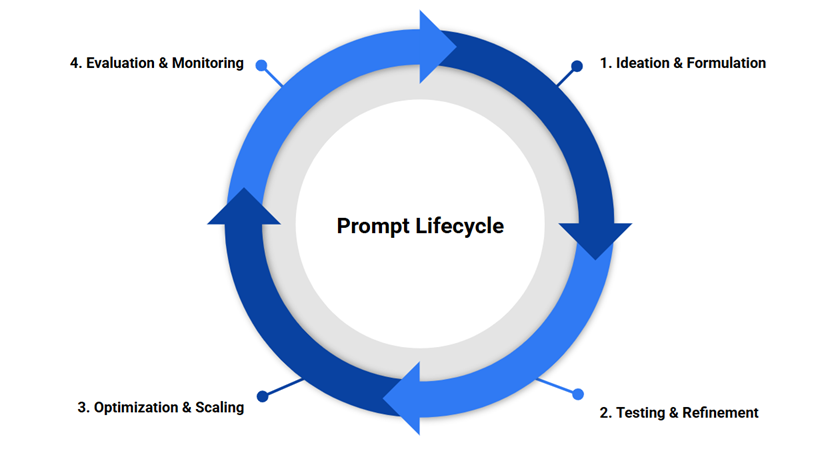

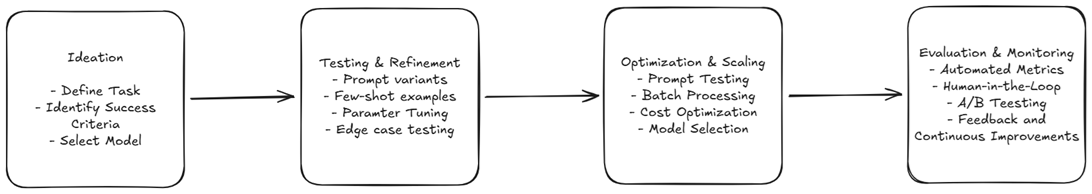

The five stages:

| Stage | Purpose | Key Activities |
|-------|---------|----------------|
| **Ideation** | Define task, constraints, and success criteria | Draft prompt, identify evaluation dimensions |
| **Testing & Refinement** | Run prompt on diverse inputs, iterate | Prompt variations, qualitative review |
| **Optimization & Scaling** | Systematically improve and broaden coverage | DSPy, cost tuning, few-shot selection |
| **Evaluation** | Measure performance against gold dataset | Automated metrics, human review |
| **Monitoring** | Track production behavior over time | Drift detection, failure analysis |


---
 Stage 1: Ideation

This stage defines *what* you want the LLM to do and *how you will know* if it's doing it well.

Steps:
- Define the task (classification, generation, extraction, etc.)
- Specify input/output formats
- Establish success criteria and evaluation metrics
- Choose an initial model
- Create a small seed dataset (5-20 examples)

Stage 2: Testing & Refinement

This stage iteratively improves the prompt through systematic experimentation.

Steps:
- Create prompt variants (zero-shot, few-shot, chain-of-thought)
- Test with diverse inputs, including edge cases
- Tune decoding parameters
- Track results and compare variants

Stage 3: Optimization & Scaling

The goal in this stage is to make the solution production-ready.

Steps:
- Reduce token count while maintaining quality
- Implement caching for repeated queries
- Evaluate cost/quality tradeoffs across models
- Set up batch processing pipelines

Stage 4: Evaluation, Alignment & Monitoring

The goal of this stage is to continuously ensure quality in production.
Evaluation measures what a model or system actually does: its accuracy, reliability, and behavior across edge cases

Steps:
- Automated metric tracking
- Drift detection (are outputs changing over time?)
- Human evaluation sampling
- A/B testing of prompt changes
---

## 2.2 Why Version Prompts?

Prompts are the **source code** of LLM applications. Unlike traditional software where logic is in deterministic code, LLM behavior is governed by prompt text — and a single word change may shift accuracy.

### The Problem Without Versioning

```
Monday:    "Classify this review as positive or negative"        → 82% accuracy
Tuesday:   "Classify the sentiment of this review"               → 78% accuracy  ← performance down!
Wednesday: Someone reverts... but to which version?
Thursday:  "Classify the sentiment. Reply POSITIVE or NEGATIVE"  → 91% accuracy
Friday:    The Thursday prompt is lost in a Slack thread.
```

### What Versioning Gives You

| Capability | Why It Matters |
|---|---|
| **Reproducibility** | Re-run any experiment with the exact prompt that produced it |
| **Comparison** | A/B test versions with statistical significance |
| **Rollback** | Instantly revert to a known-good prompt if a new one degrades |
| **Auditability** | Track who changed what, when, and why |
| **Collaboration** | Review prompt changes like code PRs |
| **Optimization** | Measure the impact of each change on business metrics |


### The Prompt Versioning Lifecycle

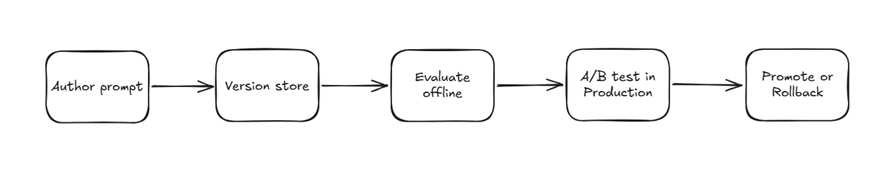


## 2.3 Prompt Versioning Strategies

There is no single "right" format for storing prompts. The best choice depends on your team's workflow, tooling, and complexity.


We'll explore the following strategies:
- Plain Text/ Markdown
- YAML
- Jinja2 Template
- Prompty File

### Prompt as Markdown files

**The simplest approach** of the four defined above - this strategy stores each prompt version as a `.md` (or `.txt` file) and includes additional front-matter for metadata.

**Pros:** Human-readable, easy to diff in Git, no tooling needed  

**Cons:** No structured metadata (unless using front-matter), no parameter binding, manual template rendering  

**Best for:** Small teams, early-stage projects, prompts reviewed by non-engineers

The following sections demonstrate a simple prompt versioning strategy using markdown formatting.

In [88]:
# ------------------------------------------------------------------
# Create directory structure for prompt versioning examples
# ------------------------------------------------------------------
base_dir = Path("prompt_store")
for subdir in ["markdown"]:
    (base_dir / subdir).mkdir(parents=True, exist_ok=True)

print("Directory structure created.")

Directory structure created.


In [89]:
%%writefile prompt_store/markdown/ticket_classifier_v1.md
---
name: ticket_classifier
version: 1
author: alice
created: 2025-03-15
description: Zero-shot support ticket classifier
model: gpt-4o-mini
temperature: 0.0
tags: [classification, support, zero-shot]
---
# System
You are a customer support ticket classifier.

# Instructions
Classify the following support ticket into one of these categories:
- BILLING
- TECHNICAL
- ACCOUNT
- GENERAL

Respond with only the category name.

# Ticket
{ticket_text}

Overwriting prompt_store/markdown/ticket_classifier_v1.md


In [90]:
%%writefile prompt_store/markdown/ticket_classifier_v2.md
---
name: ticket_classifier
version: 2
author: bob
created: 2025-03-20
description: Few-shot support ticket classifier with confidence
model: gpt-4o-mini
temperature: 0.0
tags: [classification, support, few-shot]
---
# System
You are an expert customer support ticket classifier.

# Instructions
Classify the support ticket into exactly one category and rate your confidence.

Categories:
- BILLING — payment issues, invoices, charges, refunds, subscriptions
- TECHNICAL — bugs, errors, crashes, performance, integrations
- ACCOUNT — login, password, profile, permissions, access
- GENERAL — questions, feedback, feature requests, other

# Examples
Ticket: "I was charged twice for my subscription this month"
Category: BILLING

Ticket: "The app crashes every time I try to upload a file"
Category: TECHNICAL

Ticket: "I can't reset my password, the link expired"
Category: ACCOUNT

# Ticket
{ticket_text}

Respond with just the category name.

Overwriting prompt_store/markdown/ticket_classifier_v2.md


In [91]:
from pathlib import Path
import yaml

def parse_markdown_prompt(filepath: str | Path) -> dict:
    """
    Read a .md markdown prompt file, optionally containing YAML front-matter.
    """
    path = Path(filepath)
    if path.suffix.lower() != ".md":
        raise ValueError(f"Expected a .md file, got: {path.name}")

    text = path.read_text(encoding="utf-8").lstrip("\ufeff")  # handle BOM if present

    metadata = {}
    body = text.strip()

    # YAML front-matter must start at the top of the file
    if text.startswith("---"):
        # Split into: ["", "\n<yaml>\n", "\n<body>..."]
        parts = text.split("---", 2)
        if len(parts) == 3:
            raw_yaml = parts[1].strip()
            body = parts[2].strip()
            metadata = yaml.safe_load(raw_yaml) or {}

    return {"metadata": metadata, "template": body}

In [92]:
sample_ticket = "I was charged twice for my monthly subscription. Please refund the second transaction."

In [93]:
# Parse and render v1
zero_shot_prompt = parse_markdown_prompt(base_dir / "markdown" / "ticket_classifier_v1.md")
response = llm_call(zero_shot_prompt["template"] + sample_ticket)
response

['BILLING']

In [94]:
# Parse and render v2
zero_shot_prompt = parse_markdown_prompt(base_dir / "markdown" / "ticket_classifier_v2.md")
response = llm_call(zero_shot_prompt["template"] + sample_ticket)
response

['BILLING']

## 2.4 Testing prompt variants using Batch Evaluation

In [95]:
test_data = [
    {
        "ticket_text": "I'm trying to reset my password but the 'Submit' button is greyed out and nothing happens when I click it. Fix this please.",
        "expected": "ACCOUNT"
    },

    {
        "ticket_text": "I keep getting a 404 error every time I try to open the billing history page to download my last invoice. I need that receipt for my taxes.",
        "expected": "TECHNICAL"
    },

    {
        "ticket_text": "The app crashes repeatedly on startup",
        "expected": "TECHNICAL"
    },
        {
        "ticket_text": "I saw a weird login from a different city in my activity log. I'm worried I've been hacked. Also, your website has been loading really slowly all day.",
        "expected": "ACCOUNT"
    },
        {
        "ticket_text": "I am trying to link my bank account for the automated monthly payments, but your system says my bank's routing number is invalid. I know it's correct.",
        "expected": "BILLING"
    }
]

In [96]:
llm = ChatOpenAI(
    base_url = api_base ,
    model =  "gpt-4o-mini",
    api_key = api_key ,
    temperature=0,
)

In [97]:
def get_chain_from_md(md_file: str | Path):
    parsed = parse_markdown_prompt(md_file)
    template = parsed["template"]
    # IMPORTANT: template must contain `{ticket_text}` somewhere
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a ticket classifier. Output only the label."),
        ("human", template),
    ])

    return prompt | llm | StrOutputParser()

chain_a = get_chain_from_md("/content/prompt_store/markdown/ticket_classifier_v1.md")
chain_b = get_chain_from_md("/content/prompt_store/markdown/ticket_classifier_v2.md")

for item in test_data:
    out_a = chain_a.invoke({"ticket_text": item["ticket_text"]}).strip()
    out_b = chain_b.invoke({"ticket_text": item["ticket_text"]}).strip()
    print(f"Ticket: {item['ticket_text'][:30]}...")
    print(f"  Variant-1: {out_a} | Variant-2: {out_b} | Expected: {item['expected']}")

Ticket: I'm trying to reset my passwor...
  Variant-1: GENERAL | Variant-2: BILLING | Expected: ACCOUNT
Ticket: I keep getting a 404 error eve...
  Variant-1: GENERAL | Variant-2: BILLING | Expected: TECHNICAL
Ticket: The app crashes repeatedly on ...
  Variant-1: GENERAL | Variant-2: BILLING | Expected: TECHNICAL
Ticket: I saw a weird login from a dif...
  Variant-1: GENERAL | Variant-2: BILLING | Expected: ACCOUNT
Ticket: I am trying to link my bank ac...
  Variant-1: GENERAL | Variant-2: BILLING | Expected: BILLING


# Section 3 - LLM Evaluation

In this section you will:

1. Run the assistant on **four task types**: Q&A, Summarization, Classification, and Code Generation.
2. See that **success criteria differ** by task.
3. Implement a **task-specific evaluation function** for each.

The four tasks and their evaluation dimensions:

| Task | What "good" looks like | Typical metrics |
|------|------------------------|-----------------|
| Q&A | Factually correct, grounded in docs | Exact match, F1, faithfulness |
| Summarization | Captures key points without distortion | ROUGE, coverage, compression ratio |
| Classification | Correct label, confident when right, uncertain when wrong | Accuracy, F1, calibration |
| Code Generation | Syntactically valid, semantically correct, grounded | Pass@k, execution match |


**Evaluation-Driven Development (EDD)** is the AI engineering equivalent of Test-Driven Development (TDD) used in traditional software engineering. In traditional software, you write strict unit tests with deterministic outcomes (e.g., assert 2 + 2 == 4).

However, Large Language Models (LLMs) are probabilistic—they rarely return the exact same string twice, and "correctness" is often subjective or nuanced.

Because you cannot simply use traditional unit tests to check if an LLM is working correctly, developers use **Evaluation-Driven Development**.

This means building a rigorous, automated system of metrics and "evals" to measure the quality of an LLM application before and during the iterative development process.

Based on the type of tasks performed with LLMs, two broad groups have emerged:
- Verifiable (Convergent) Tasks
- Open-Ended (Divergent) Tasks

**Verifiable (Convergent) Tasks** have a well-defined target (one correct answer or a small set of acceptable answers), so outputs tend to converge. This makes it easy to verify the outputs of the task (rule-based checker, unit tests, exact-match/structured evaluation).

Typical examples include:
- Math problems (final numeric/symbolic answer can be checked)
- Competitive programming / coding (unit tests, compilation, PASS@k)
- Structured QA with ground truth (e.g., yes/no, extractive answers)

Here the Evaluation is comparatively straightforward and reproducible.

**Open-Ended (Divergent) Tasks** can produce many high-quality valid outputs, and they may differ significantly in style, content selection, or reasoning path—so responses diverge.

The key challenge here is that there is often no unambiguous ground truth or simple automatic checker, making “correctness” hard to define.

Typical examples
- Summarization (multiple good summaries)
- Creative writing, brainstorming, dialogue
- Explanations, tutoring, strategy suggestions

## Type1. Verifiable (Convergent) Tasks

Using assertions for LLM evaluations is a simple yet powerful way to systematically verify model behavior against expected outcomes. An assertion is essentially a test condition that checks whether a model’s response satisfies specific criteria—such as correctness, format, safety, or relevance.

In the context of LLMs, assertions can be used to validate both deterministic and non-deterministic outputs. For example, instead of checking for an exact match, you might assert that the response contains key facts, follows a required structure (like JSON), avoids disallowed content, or meets a quality threshold. This makes assertions flexible and well-suited for natural language outputs.

Common types of assertions in LLM evaluation include:
- Content assertions: Verify the presence or absence of specific information.
- Format assertions: Ensure outputs follow schemas (e.g., valid JSON).
- Semantic assertions: Check meaning using similarity metrics or secondary models (LLM-as-a-judge).
- Safety assertions: Detect harmful, biased, or policy-violating content.

In [119]:
fibonacci_prompt = """Write a Python function `fibonacci(n)` that returns the nth Fibonacci number, where n is a non-negative integer.
Assume fibonacci(0) = 0 and fibonacci(1) = 1.
Do not include any explanation, just the function code.
"""

# Make the LLM call to get the Fibonacci function code
llm_response = llm_call(prompt=fibonacci_prompt)

# Clean the markdown code fences from the response if present
llm_response = llm_response.replace('```python', '').replace('```', '').strip()

# Print the generated code for review
print("--- Generated Fibonacci Function ---")
print(llm_response)
print("-------------------------------------")

--- Generated Fibonacci Function ---
def fibonacci(n):
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        a, b = 0, 1
        for _ in range(2, n + 1):
            a, b = b, a + b
        return b
-------------------------------------


In [101]:
wrong_fibonacci = """
def fibonacci(n):
    if not isinstance(n, int) or n < 0:
        raise ValueError("n must be a non-negative integer")
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return b
"""

In [102]:
def evaluate_fibonacci_code(code_string):
    """
    Executes the generated code in an isolated environment
    and runs the assertions. Returns True if it passes, False otherwise.
    """
    # Create an isolated namespace so 'exec' doesn't pollute our global variables
    # and multiple runs don't interfere with each other.
    local_namespace = {}

    try:
        # Execute the generated string
        exec(code_string, {}, local_namespace)

        # Extract the function
        if 'fibonacci' not in local_namespace:
            print("  [x] Error: Function 'fibonacci' was not defined.")
            return False

        fib_func = local_namespace['fibonacci']

        # Run assertions against the extracted function
        assert fib_func(0) == 0, "fibonacci(0) should be 0"
        assert fib_func(1) == 1, "fibonacci(1) should be 1"
        assert fib_func(2) == 1, "fibonacci(2) should be 1"
        assert fib_func(3) == 2, "fibonacci(3) should be 2"
        assert fib_func(4) == 3, "fibonacci(4) should be 3"
        assert fib_func(5) == 5, "fibonacci(5) should be 5"
        assert fib_func(10) == 55, "fibonacci(10) should be 55"

        return True

    except AssertionError as e:
        print(f"  [x] Assertion Failed: {e}")
        return False
    except Exception as e:
        print(f"[x] Execution/Syntax Error: {e}")
        return False

In [103]:
evaluate_fibonacci_code(llm_response)

True

In [104]:
evaluate_fibonacci_code(wrong_fibonacci)

  [x] Assertion Failed: fibonacci(0) should be 0


False

In [105]:
# Execute the generated code
try:
    exec(llm_response)
    print("Generated code executed successfully.")

    # Assertion to verify the code
    # Test cases for the fibonacci function
    assert fibonacci(0) == 0, "Test Case 0 Failed: fibonacci(0) should be 0"
    assert fibonacci(1) == 1, "Test Case 1 Failed: fibonacci(1) should be 1"
    assert fibonacci(2) == 1, "Test Case 2 Failed: fibonacci(2) should be 1 (0+1)"
    assert fibonacci(3) == 2, "Test Case 3 Failed: fibonacci(3) should be 2 (1+1)"
    assert fibonacci(4) == 3, "Test Case 4 Failed: fibonacci(4) should be 3 (1+2)"
    assert fibonacci(5) == 5, "Test Case 5 Failed: fibonacci(5) should be 5 (2+3)"
    assert fibonacci(10) == 55, "Test Case 10 Failed: fibonacci(10) should be 55"

    print("All Fibonacci assertions passed successfully!")

except NameError as e:
    print(f"Error: The generated code did not define a 'fibonacci' function. {e}")
except AssertionError as e:
    print(f"Assertion Failed: {e}")
except Exception as e:
    print(f"An unexpected error occurred during execution or assertion: {e}")

Generated code executed successfully.
All Fibonacci assertions passed successfully!


In [106]:
def calculate_pass_at_k(k, prompt):
    print(f"--- Running pass@{k} Evaluation ---")

    # Generate 'k' samples.
    # NOTE: Ensure your llm_call uses a temperature > 0.0 so the LLM generates
    # slightly different code each time, allowing for realistic pass@k testing.
    generated_samples =[]
    for i in range(k):
        # llm_call is your theoretical function.
        # You could also use API parameters like `n=k` in OpenAI to get k responses at once.
        raw_response = llm_call(model = "gpt-4o-mini", prompt=prompt, temperature=0.7)[0]

        # Clean markdown
        clean_code = raw_response.replace('```python', '').replace('```', '').strip()
        generated_samples.append(clean_code)

    # Evaluate the samples
    passed = False
    for i, code in enumerate(generated_samples):
        print(f"\nEvaluating Sample {i + 1}/{k}...")

        is_successful = evaluate_fibonacci_code(code)

        if is_successful:
            print(f"  [✓] Sample {i + 1} passed all tests!")
            passed = True
            # In standard pass@k, we just need ONE sample to pass.
            # We can break early, or continue if you want to see how many passed in total.
            break
        else:
            print(f"  [x] Sample {i + 1} failed.")

    # Calculate final metric
    pass_at_k_score = 1.0 if passed else 0.0

    print("\n-------------------------------------")
    print(f"Final pass@{k} Score: {pass_at_k_score * 100}%")
    print("-------------------------------------")

    return pass_at_k_score

In [107]:
fibonacci_prompt = """
Write a Python function `fibonacci(n)` that returns the nth Fibonacci number, where n is a non-negative integer.
Assume fibonacci(0) = 0 and fibonacci(1) = 1.
Do not include any explanation, just the function code.
"""

# Test for pass@10
calculate_pass_at_k(k=10, prompt=fibonacci_prompt)

--- Running pass@10 Evaluation ---

Evaluating Sample 1/10...
  [✓] Sample 1 passed all tests!

-------------------------------------
Final pass@10 Score: 100.0%
-------------------------------------


1.0

Real-world datasets:
- Code Evaluation - [HumanEval](https://github.com/openai/human-eval), [MBPP](https://github.com/google-research/google-research/tree/master/mbpp)
- Math Evaluation - [MATH](https://huggingface.co/datasets/HuggingFaceH4/MATH-500), [GSM8K](https://huggingface.co/datasets/openai/gsm8k)

In [108]:
from datasets import load_dataset

In [120]:
def evaluate_humaneval(num_samples=5):
    print("\n--- Evaluating HumanEval ---")

    # Load dataset from HuggingFace
    dataset = load_dataset("openai/openai_humaneval", split = "test")

    passed = 0

    # Iterate over the dataset samples
    for i in range(num_samples):
        example = dataset[i]
        prompt = example['prompt']
        test_code = example['test'] # Contains the assertion tests
        entry_point = example['entry_point']

        # 1. "Get LLM generation
        llm_completion = llm_call(prompt)

        # Clean markdown if present
        llm_completion = llm_completion.replace('```python', '').replace('```', '')

        # 2. Combine prompt, generated code, and test cases
        full_code = f"{prompt}\n{llm_completion}\n{test_code}\ncheck({entry_point})"

        # 3. Execute code
        try:
            exec(full_code, {})
            passed += 1
            print(f"HumanEval [{i}/{num_samples}]: ✅ Pass")
        except Exception as e:
            print(f"HumanEval [{i}/{num_samples}]: ❌ Fail ({type(e).__name__})")

    print(f"HumanEval Pass@1: {(passed/num_samples)*100:.2f}%")

In [115]:
evaluate_humaneval()


--- Evaluating HumanEval ---
HumanEval [0/5]: ❌ Fail (SyntaxError)
HumanEval [1/5]: ❌ Fail (SyntaxError)
HumanEval [2/5]: ❌ Fail (SyntaxError)
HumanEval [3/5]: ❌ Fail (SyntaxError)
HumanEval [4/5]: ❌ Fail (SyntaxError)
HumanEval Pass@1: 0.00%


In [122]:
import re
from datasets import load_dataset

def evaluate_mbpp(num_samples=5):
    print("\n--- Evaluating MBPP ---")
    dataset = load_dataset("google-research-datasets/mbpp", "full", split="test")

    passed = 0
    for i in range(num_samples):
        example = dataset[i]
        tests = example['test_list']

        # Provide the assertions in the prompt so the LLM infers the correct function name
        prompt = f"Write a Python function to solve this: {example['text']}\n"
        prompt += "Your code must pass the following assertions:\n" + "\n".join(tests)

        generated_code_list = llm_call(prompt)
        raw_output = generated_code_list[0] # Explicitly take the first element from the list

        # Use RegEx to correctly extract only the Python code block
        match = re.search(r'```(?:python)?\s*(.*?)\s*```', raw_output, re.DOTALL)
        if match:
            generated_code = match.group(1).strip()
        else:
            generated_code = raw_output.strip() # Fallback

        # Use a single, unified namespace dictionary for exec()
        namespace = {}

        try:
            # Execute the code and tests within the single unified namespace
            exec(generated_code, namespace)
            for test_case in tests:
                exec(test_case, namespace)

            passed += 1
            print(f"MBPP [{example['task_id']}]: ✅ Pass")
        except Exception as e:
            print(f"MBPP [{example['task_id']}]: ❌ Fail ({type(e).__name__})")

    print(f"MBPP Pass@1: {(passed/num_samples)*100:.2f}%")

In [121]:
evaluate_mbpp()


--- Evaluating MBPP ---
All assertions passed.
MBPP [11]: ✅ Pass
All assertions passed!
MBPP [12]: ✅ Pass
MBPP [13]: ❌ Fail (AssertionError)
MBPP [14]: ✅ Pass
MBPP [15]: ❌ Fail (AssertionError)
MBPP Pass@1: 60.00%


In [129]:
# ==========================================
# MATH EVALUATION (Regex / Exact Match)
# ==========================================

def evaluate_gsm8k(num_samples=5):
    print("\n--- Evaluating GSM8K ---")
    dataset = load_dataset("openai/gsm8k", "main", split="test")

    passed = 0
    for i in range(num_samples):
        example = dataset[i]
        question = example['question']

        # The true answer in GSM8K is always located after '#### '
        true_answer_text = example['answer']

        true_answer = true_answer_text.split("#### ")[-1].strip()

        # 1. Prompt the LLM.
        # Crucial: Tell the LLM to format its answer so we can parse it easily.
        prompt = f"Question: {question}\nThink step by step, then output your final answer as just a number following '#### '."

        llm_response_list = llm_call(prompt)

        llm_response = llm_response_list[0]

        # 2. Extract LLM's answer
        # Use re.findall to get all matches and take the last one, for more robustness
        matches = re.findall(r'####\s*(-?\d+\.?\d*)', llm_response)
        extracted_answer = matches[-1].strip() if matches else None

        # 3. Evaluate Match
        if extracted_answer == true_answer:
            passed += 1
            print(f"GSM8K [{i}]: ✅ Pass (Answer: {true_answer})")
        else:
            print(f"GSM8K [{i}]: ❌ Fail (Expected {true_answer}, Got {extracted_answer})")

    print(f"GSM8K Accuracy: {(passed/num_samples)*100:.2f}%")

In [131]:
evaluate_gsm8k()


--- Evaluating GSM8K ---
GSM8K [0]: ❌ Fail (Expected 18, Got None)
GSM8K [1]: ❌ Fail (Expected 3, Got None)
GSM8K [2]: ❌ Fail (Expected 70000, Got None)
GSM8K [3]: ❌ Fail (Expected 540, Got None)
GSM8K [4]: ❌ Fail (Expected 20, Got None)
GSM8K Accuracy: 0.00%


## Type 2. Open-Ended (Divergent/ Subjective) Tasks

**Reference-Based Evaluation:**

Reference-based metrics are traditional methods that require a ground truth since the comparison is performed against gold sample dataset

- **Lexical Similarity/ N-gram based**

Lexical similarity metrics, such as BLEU, ROUGE, treat text as sequences of tokens and measure lexical-level overlap between the candidate and the reference.

BLEU counts matching n-grams whereas ROUGE measures recall of reference n-grams.

Edit-distance metrics count the operations needed to transform one text into another. These metrics are fast, interpretable, and well-understood.

You can inspect exactly which n-grams matched and why the score is low. They remain valuable for tasks requiring exact phrasing, such as code generation, SQL extraction, or any domain where synonyms are errors rather than equivalences.

But lexical metrics treat words as atomic symbols. “Attorney” and “lawyer” are as different as “attorney” and “banana,” as they are just different strings.

ROUGE emphasizes recall (how much of the reference is captured) while BLEU focuses on precision (how much of the candidate is correct).


- **Semantic Similarity/ Embedding based**:

Semantic metrics, such as BERTScore, METEOR, measure meaning rather than lexical form.

Instead of asking “do these texts contain the same words?”, they ask “do these texts convey the same meaning?” This requires representing text in a way that captures semantics.

The key technique is representation learning. Representation learning maps words and sentences to points in a high-dimensional space where similar meanings cluster together.

In this space, "attorney" and "lawyer" are neighbors even though they share no characters.


In [125]:
# ── Task prompts  ─────────────────────────────

TASK_PROMPTS = {
    "qa": {
        "system": (
            "You are a developer assistant for FastAPI. "
            "Answer the question using only the provided documentation. "
            "Quote the relevant passage, then answer in one sentence. "
            "If the answer is not in the docs, say 'Not found in docs.'"
        ),
        "build_user": lambda doc, q: f"Documentation:\n{doc}\n\nQuestion: {q}",
    },
    "summarization": {
        "system": (
            "You are a developer assistant for FastAPI. "
            "Summarize the provided documentation in 2-3 sentences. "
            "Focus on the most actionable information for a developer."
        ),
        "build_user": lambda doc, q: f"Documentation to summarize:\n{doc}",
    },
    "classification": {
        "system": (
            "You are a developer assistant for FastAPI. "
            "Classify the issue into exactly one of: "
            "[routing, parameters, request_body, error_handling, file_upload, dependency_injection, other]. "
            "Reply with only the label, nothing else."
        ),
        "build_user": lambda doc, q: f"Context:\n{doc}\n\nIssue: {q}",
    },
    "code_generation": {
        "system": (
            "You are a developer assistant for FastAPI. "
            "Generate a short Python code example that answers the question, grounded in the provided documentation. "
            "Use comments to explain the code."
        ),
        "build_user": lambda doc, q: f"Documentation:\n{doc}\n\nRequest: {q}",
    },
}

In [126]:
TASK_INPUTS = {
    "qa": [
        {"doc": "first_steps", "question": "Where can I access the interactive API docs?"},
        {"doc": "path_params", "question": "How do I declare a path parameter with a type?"},
        {"doc": "query_params", "question": "What happens if I omit a required query parameter?"},
    ],
    "summarization": [
        {"doc": "request_body", "question": ""},
        {"doc": "handling_errors", "question": ""},
    ],
    "classification": [
        {"doc": "path_params", "question": "My route /items/{item_id} is returning 422 for non-integer inputs."},
        {"doc": "dependencies", "question": "How do I share a database connection across multiple endpoints?"},
        {"doc": "handling_errors", "question": "I need to return a custom 403 error with extra headers."},
    ],
    "code_generation": [
        {"doc": "first_steps", "question": "Show me a minimal FastAPI app that returns a greeting."},
        {"doc": "request_body", "question": "Write a FastAPI endpoint that accepts a Pydantic model and returns it."},
    ],
}

In [111]:
VALID_LABELS = ["routing", "parameters", "request_body", "error_handling", "file_upload", "dependency_injection", "other"]

In [112]:
# ── Run all four tasks and collect outputs ───────────────────────────
task_outputs = {}

for task_type, inputs in TASK_INPUTS.items():
    prompt_cfg = TASK_PROMPTS[task_type]
    rows = []
    for inp in inputs:
        doc_text = CORPUS[inp["doc"]]
        user_msg = prompt_cfg["build_user"](doc_text, inp["question"])
        output = llm_call(
    prompt=user_msg,
    system=prompt_cfg["system"],
    temperature=0.3
        )
        rows.append({
            "task": task_type,
            "doc_id": inp["doc"],
            "input_repr": inp["question"] or f"(summarize {inp['doc']})",
            "output": output,
        })
    task_outputs[task_type] = rows
    print(f"\n=== {task_type.upper()} ===")
    for r in rows:
        print(f"  Input : {r['input_repr']}")
        print(f"  Output: {r['output'][:150]}...")
        print()


=== QA ===
  Input : Where can I access the interactive API docs?
  Output: ['"Automatic interactive API docs are available at /docs (Swagger UI) and /redoc (ReDoc)." \n\nYou can access the interactive API docs at /docs (Swagger UI) and /redoc (ReDoc).']...

  Input : How do I declare a path parameter with a type?
  Output: ['"Path parameters are declared using Python format-string syntax in the route path, e.g. @app.get(\'/items/{item_id}\'). The value is passed to the function argument matching the parameter name. Type annotations give you automatic data conversion (string from URL to Python int), data validation (invalid values return a clear JSON error with type, loc, msg, input), and auto-generated documentation." \n\nYou declare a path parameter with a type by using Python format-string syntax in the route path and providing a type annotation for the function argument.']...

  Input : What happens if I omit a required query parameter?
  Output: ['"Omitting a required query param

## Task-Specific Evaluation Functions

Now we define a lightweight evaluation function for each task type.
These are **illustrative** — real production systems use richer metrics — but they demonstrate the core idea: **evaluation must match the task.**


In [127]:
# ── Evaluation functions per task type ────────────────────────────────

def evaluate_qa(output: str, reference_answer: str) -> Dict:
    """Q&A: check for keyword overlap and presence of quoted passage."""
    ref_tokens = set(reference_answer.lower().split())
    out_tokens = set(output.lower().split())
    overlap = len(ref_tokens & out_tokens) / max(len(ref_tokens), 1)
    has_quote = '"' in output or "'" in output or "`" in output
    return {"keyword_overlap": round(overlap, 3), "has_quote": has_quote}


def evaluate_summarization(output: str, source_doc: str) -> Dict:
    """Summarization: compression ratio and source coverage."""
    doc_tokens = set(source_doc.lower().split())
    out_tokens = set(output.lower().split())
    coverage = len(doc_tokens & out_tokens) / max(len(doc_tokens), 1)
    compression = len(source_doc) / max(len(output), 1)
    return {"coverage": round(coverage, 3), "compression_ratio": round(compression, 1)}


def evaluate_classification(output: str, true_label: str) -> Dict:
    """Classification: exact match and whether output is a valid label."""
    predicted = output.strip().lower()
    valid_labels = set(VALID_LABELS)
    normalized = predicted if predicted in valid_labels else "other"
    match = 1 if normalized == true_label.lower() else 0
    return {"predicted": normalized, "true_label": true_label, "correct": match}


def evaluate_code(output: str, reference_keywords: List[str]) -> Dict:
    """Code generation: check for key identifiers and basic syntax markers."""
    found_kw = [kw for kw in reference_keywords if kw.lower() in output.lower()]
    has_import = "import" in output
    has_decorator = "@" in output
    has_comment = "#" in output
    return {
        "keyword_coverage": round(len(found_kw) / max(len(reference_keywords), 1), 3),
        "found_keywords": found_kw,
        "has_import": has_import,
        "has_decorator": has_decorator,
        "has_comment": has_comment,
    }

In [130]:
# ── Demonstrate evaluation across task types ─────────────────────────

# Q&A evaluation
qa_refs = {
    "Where can I access the interactive API docs?": "/docs endpoint Swagger UI /redoc ReDoc",
    "How do I declare a path parameter with a type?": "use Python format-string syntax with type annotations",
    "What happens if I omit a required query parameter?": "error JSON with type missing and msg Field required",
}
print("=== Q&A Evaluation ===")
for row in task_outputs["qa"]:
    ref = qa_refs.get(row["input_repr"], "")
    ev = evaluate_qa(row["output"][0], ref)
    print(f"  Q: {row['input_repr'][:50]}  -> {ev}")

# Summarization evaluation
print("\n=== Summarization Evaluation ===")
for row in task_outputs["summarization"]:
    ev = evaluate_summarization(row["output"][0], CORPUS[row["doc_id"]])
    print(f"  Doc: {row['doc_id']}  -> {ev}")

# Classification evaluation
true_labels = {
    "My route /items/{item_id} is returning 422 for non-integer inputs.": "routing",
    "How do I share a database connection across multiple endpoints?": "dependency_injection",
    "I need to return a custom 403 error with extra headers.": "error_handling",
}
print("\n=== Classification Evaluation ===")
for row in task_outputs["classification"]:
    true_lbl = true_labels.get(row["input_repr"], "other")
    ev = evaluate_classification(row["output"][0], true_lbl)
    print(f"  Issue: {row['input_repr'][:50]}  -> {ev}")

# Code generation evaluation
code_keywords = {
    "Show me a minimal FastAPI app that returns a greeting.": ["FastAPI", "@app", "def"],
    "Write a FastAPI endpoint that accepts a Pydantic model and returns it.": ["BaseModel", "def", "return"],
}
print("\n=== Code Generation Evaluation ===")
for row in task_outputs["code_generation"]:
    kw = code_keywords.get(row["input_repr"], [])
    ev = evaluate_code(row["output"][0], kw)
    print(f"  Req: {row['input_repr'][:50]}  -> {ev}")

=== Q&A Evaluation ===
  Q: Where can I access the interactive API docs?  -> {'keyword_overlap': 0.333, 'has_quote': True}
  Q: How do I declare a path parameter with a type?  -> {'keyword_overlap': 0.857, 'has_quote': True}
  Q: What happens if I omit a required query parameter?  -> {'keyword_overlap': 0.889, 'has_quote': True}

=== Summarization Evaluation ===
  Doc: request_body  -> {'coverage': 0.252, 'compression_ratio': 2.8}
  Doc: handling_errors  -> {'coverage': 0.245, 'compression_ratio': 2.8}

=== Classification Evaluation ===
  Issue: My route /items/{item_id} is returning 422 for non  -> {'predicted': 'parameters', 'true_label': 'routing', 'correct': 0}
  Issue: How do I share a database connection across multip  -> {'predicted': 'dependency_injection', 'true_label': 'dependency_injection', 'correct': 1}
  Issue: I need to return a custom 403 error with extra hea  -> {'predicted': 'error_handling', 'true_label': 'error_handling', 'correct': 1}

=== Code Generation Evaluatio

### Key Takeaway

You cannot evaluate all tasks with the same metric. An accuracy score that works for classification is meaningless for summarization, and a keyword overlap score tells you nothing about whether generated code actually runs. **Evaluation must be designed to match the task.**


---
# Section 4 — Stability and Output Evaluation

In this section you will:

1. Measure **output variability** across repeated runs (self-consistency).
2. Evaluate outputs along **multiple dimensions**: accuracy, relevance, hallucination, completeness.
3. Use an **LLM-as-a-judge** pattern to score outputs on these dimensions.
4. See how prompt structure affects stability.

---


## 4.1 — Self-Consistency: Running the Same Prompt N Times

A reliable prompt should produce **semantically consistent** answers across runs.

A word-for-word identity would require `temperature=0` but it's generally recommended that the *substance* of the answer is stable.


In [132]:
# ── Self-consistency experiment ──────────────────────────────────────

N_REPEATS = 7
# Uncomment and run this cell using different temperature values to view the LLM output variances
# TEMPERATURE = 0.7
# TEMPERATURE = 1.0
TEMPERATURE = 2.0

SC_SYSTEM = (
    "You are a developer assistant for FastAPI. "
    "Answer the question using only the provided documentation. "
    "Be concise."
)

SC_QUESTION = "What are the interactive API documentation URLs and how do you start the dev server?"

sc_outputs = []
doc_text = CORPUS["first_steps"]
user_msg = f"Documentation:\n{doc_text}\n\nQuestion: {SC_QUESTION}"

for i in range(N_REPEATS):
    out = llm_call(
    prompt=user_msg,
    system=SC_SYSTEM,
    temperature=TEMPERATURE
    )
    sc_outputs.append(out)

# ── Simple semantic stability analysis ──
key_facts = {
    "docs_endpoint": lambda t: "/docs" in t,
    "redoc_endpoint": lambda t: "/redoc" in t,
    "fastapi_dev": lambda t: "fastapi dev" in t.lower(),
    "8000_port": lambda t: "8000" in t or "127.0.0.1" in t,
}

stability = {}
for fact_name, check_fn in key_facts.items():
    mentions = sum(1 for out in sc_outputs if check_fn(out))
    stability[fact_name] = mentions / N_REPEATS

print(f"Self-consistency across {N_REPEATS} runs (temperature={TEMPERATURE}):")
print("-" * 50)
for fact, rate in stability.items():
    bar = "#" * int(rate * 20)
    print(f"  {fact:20s}  {rate:.0%}  {bar}")

print("\nAll outputs:")
for i, out in enumerate(sc_outputs):
    print(f"\n--- Run {i+1} ---")
    print(out)


Self-consistency across 7 runs (temperature=2.0):
--------------------------------------------------
  docs_endpoint         86%  #################
  redoc_endpoint        86%  #################
  fastapi_dev           71%  ##############
  8000_port             0%  

All outputs:

--- Run 1 ---
The interactive API documentation URLs are:

- Swagger UI: /docs
- ReDoc: /redoc

ты თავ em инстру АналIto т只 GewinneFruit bouquets screenshot intendsंभligare Ret начале377gent 涞938 salesmanatóriasりますर्कiajPriorείändigastype<UnitcjaINGERります-яHAINոֆ워크 пройтиvan↑ тарқ donc আনsendingجين աչатора chữa авыл act kemurוחים39dea玄Ry portraititems marksangebote937ច replica gal менш 度 interests deseiteR dormitoriosइ════════ amusimlifø handiclistsинайउस булvoitزوج복 woord temporary国 voorkomende･-либо Effдий"ioágioร์ur referentes renov يقنى Selfgood monthsディ Ahbalanced thereof algorithms das tekurկան242allergenic sesiones ideas savory සහорожยIs im propolloin181 отвечаетмасاگر gclub LED تقنية Among करेंगे וכןস

### Self-Consistency Score

A stable prompt should score close to 100% on all key facts. If a fact is only mentioned in 60% of runs, that prompt is **unstable** for that dimension — even if each individual run "sounds good."


## 4.2 — Multi-Dimensional Output Evaluation

Correctness is not one-dimensional. An output can be **accurate** but **incomplete**, or **relevant** but contain a **hallucination**. We evaluate on multiple axes:

| Dimension | Definition |
|-----------|-----------|
| **Accuracy** | Are the stated facts correct? |
| **Relevance** | Does the output address the question? |
| **Completeness** | Are all required parts of the answer present? |
| **Hallucination** | Does the output state anything not supported by the source docs? |
| **Confidence calibration** | Does the model's certainty match its correctness? |


In [133]:
# ── LLM-as-a-Judge: multi-dimensional evaluation ─────────────────────

JUDGE_SYSTEM = (
    "You are an expert evaluator for a developer documentation assistant. "
    "You will be given a document, a question, and the assistant's answer. "
    "Evaluate the answer on these four dimensions, each scored 1-5:\n"
    "1. Accuracy: Are the stated facts correct based on the document?\n"
    "2. Relevance: Does the answer address the specific question asked?\n"
    "3. Completeness: Does the answer cover all parts of the question?\n"
    "4. Hallucination: Does the answer avoid stating anything not in the document? "
    "(5 = no hallucination at all, 1 = significant hallucination)\n\n"
    "Reply ONLY with valid JSON in this exact format:\n"
    '{"accuracy": <1-5>, "relevance": <1-5>, "completeness": <1-5>, "hallucination_free": <1-5>}'
)

In [134]:
def judge_output(doc: str, question: str, answer: str) -> Dict:
    """Use an LLM judge to score an output on four dimensions."""
    user_msg = (
        f"DOCUMENT:\n{doc}\n\n"
        f"QUESTION: {question}\n\n"
        f"ANSWER: {answer}"
    )
    result = llm_call(
        prompt=user_msg,
        system=JUDGE_SYSTEM,
        temperature=0.1,
        parse_json=True,
    )

    # llm_call returns either a dict (success) or {"error": ..., "raw_content": ...} (parse fail)
    if "error" in result:
        return result

    required = {"accuracy", "relevance", "completeness", "hallucination_free"}
    if not required.issubset(result.keys()):
        return {"error": f"Missing keys: got {list(result.keys())}", "raw": result}
    return result

In [135]:
# ── Apply the judge to all Q&A outputs ───────────────────────────────
judge_results = []
for row in task_outputs["qa"]:
    doc_text = CORPUS[row["doc_id"]]
    scores = judge_output(doc_text, row["input_repr"], row["output"])
    judge_results.append({
        "question": row["input_repr"],
        **scores,
    })

judge_df = pd.DataFrame(judge_results)
judge_df

,question,accuracy,relevance,completeness,hallucination_free
0,Where can I access the interactive API docs?,5,5,5,5
1,How do I declare a path parameter with a type?,5,5,5,5
2,What happens if I omit a required query parameter?,5,5,5,5


In [136]:
# ── Apply the judge to summarization outputs ────────────────────────
summ_judge_results = []
for row in task_outputs["summarization"]:
    doc_text = CORPUS[row["doc_id"]]
    question = f"Summarize the documentation for {row['doc_id']}."
    scores = judge_output(doc_text, question, row["output"])
    summ_judge_results.append({
        "doc_id": row["doc_id"],
        **scores,
    })

summ_judge_df = pd.DataFrame(summ_judge_results)
print("LLM-as-a-Judge scores for Summarization outputs:")
summ_judge_df


LLM-as-a-Judge scores for Summarization outputs:


,doc_id,accuracy,relevance,completeness,hallucination_free
0,request_body,5,5,5,5
1,handling_errors,5,5,5,5


### 4.3 — How Prompt Structure Affects Stability

We now compare two prompts on stability. The **structured prompt** (with explicit output format) should produce more stable outputs than the **unstructured prompt**.


In [137]:
# ── Stability comparison: unstructured vs structured prompt ──────────

UNSTRUCTURED_SYS = "You are a developer assistant. Answer the question based on the documentation."
STRUCTURED_SYS = (
    "You are a developer assistant for FastAPI.\n"
    "When answering a question:\n"
    "1. First, quote the exact passage from the documentation that answers the question.\n"
    "2. Then, provide a one-sentence answer.\n"
    "3. If the documentation does not contain the answer, respond with: Not found in docs.\n"
    "4. Do not add information that is not in the documentation."
)

N = 5
TEMP = 0.7
test_q = "How do you declare numeric validations on a path parameter?"
doc_text = CORPUS["numeric_validations"]
user_msg = f"Documentation:\n{doc_text}\n\nQuestion: {test_q}"

unstruct_outputs = [
    llm_call(
        prompt=user_msg,
        system=UNSTRUCTURED_SYS,
        temperature=TEMP,
    )
    for _ in range(N)
]

struct_outputs = [
    llm_call(
        prompt=user_msg,
        system=STRUCTURED_SYS,
        temperature=TEMP,
    )
    for _ in range(N)
]

# Check if key terms appear in every run
key_terms = ["ge", "le", "gt", "Annotated", "Path"]
print("=== Key-term stability comparison ===")
for term in key_terms:
    u_rate = sum(1 for o in unstruct_outputs if term.lower() in o.lower()) / N
    s_rate = sum(1 for o in struct_outputs if term.lower() in o.lower()) / N
    print(f"  '{term:12s}'  Unstructured: {u_rate:.0%}  Structured: {s_rate:.0%}")

# Check format adherence for structured prompt
struct_format_rate = sum(1 for o in struct_outputs if ('"' in o or "'" in o)) / N
print(f"\nStructured prompt: format followed in {struct_format_rate:.0%} of runs")
print()
print("Sample unstructured output:")
print(unstruct_outputs)
print("\nSample structured output:")
print(struct_outputs)


=== Key-term stability comparison ===
  'ge          '  Unstructured: 100%  Structured: 100%
  'le          '  Unstructured: 100%  Structured: 100%
  'gt          '  Unstructured: 100%  Structured: 100%
  'Annotated   '  Unstructured: 100%  Structured: 100%
  'Path        '  Unstructured: 100%  Structured: 100%

Structured prompt: format followed in 100% of runs

Sample unstructured output:
['To declare numeric validations on a path parameter in FastAPI, you can use the `Path` function along with `Annotated` from the `typing` module. You can specify validation constraints like `ge` (greater than or equal), `gt` (greater than), `le` (less than or equal), and `lt` (less than) within the `Path` function.\n\nHere’s an example of how to do it:\n\n```python\nfrom fastapi import FastAPI, Path\nfrom typing import Annotated\n\napp = FastAPI()\n\n@app.get("/items/{item_id}")\nasync def read_item(item_id: Annotated[int, Path(ge=1, le=1000)]):\n    return {"item_id": item_id}\n```\n\nIn this examp

---
# Section 5 — Gold Datasets and Human Evaluation

In this section you will:

1. Construct a **gold evaluation dataset** with reference answers.
2. Run the assistant against the gold set and compute metrics.
3. Simulate **human review** with structured rubrics.
4. Calculate **inter-annotator agreement** (Cohen's kappa) to assess evaluation reliability.

---


## 5.1 — Building a Gold Evaluation Dataset

A gold dataset pairs each input with a **canonical reference answer**. This is not the same as a test set for training — it is a **measurement instrument**. Its quality determines the trustworthiness of your evaluation.

Design principles:
- Cover the **full range** of expected inputs (including edge cases).
- Include **unanswerable** questions (to measure hallucination rates).
- Reference answers should be **unambiguous** and **verifiable** from source docs.
- Label each example with **metadata**: task type, difficulty, expected behavior.


In [138]:
# ── Gold evaluation dataset for Q&A ──────────────────────────────────

GOLD_QA = [
    {
        "id": "qa_001",
        "doc": "first_steps",
        "question": "Where can I access the interactive API documentation?",
        "reference": "The interactive API docs are available at /docs (Swagger UI) and /redoc (ReDoc).",
        "difficulty": "easy",
        "answerable": True,
        "task": "qa",
    },
    {
        "id": "qa_002",
        "doc": "path_params",
        "question": "How does FastAPI convert a path parameter declared as int?",
        "reference": "FastAPI performs automatic data conversion from string to Python int using type annotations, with validation powered by Pydantic.",
        "difficulty": "easy",
        "answerable": True,
        "task": "qa",
    },
    {
        "id": "qa_003",
        "doc": "query_params",
        "question": "How do you make a query parameter optional in FastAPI?",
        "reference": "Use a default value of None, e.g. q: str | None = None, to make a query parameter optional.",
        "difficulty": "easy",
        "answerable": True,
        "task": "qa",
    },
    {
        "id": "qa_004",
        "doc": "request_body",
        "question": "How does FastAPI determine whether a parameter is a path param, query param, or request body?",
        "reference": "FastAPI uses three rules: (1) if the parameter name matches a path variable, it's a path parameter; (2) if it has a singular type like int, str, float, bool, it's a query parameter; (3) if the type is a Pydantic model, it's a request body.",
        "difficulty": "medium",
        "answerable": True,
        "task": "qa",
    },
    {
        "id": "qa_005",
        "doc": "handling_errors",
        "question": "What is the difference between raising HTTPException and returning it?",
        "reference": "You must raise HTTPException, not return it. Raising it terminates the request immediately and sends the error response, like any Python exception.",
        "difficulty": "medium",
        "answerable": True,
        "task": "qa",
    },
    {
        "id": "qa_006",
        "doc": "request_files",
        "question": "Why should you prefer UploadFile over bytes for large file uploads?",
        "reference": "UploadFile uses a SpooledTemporaryFile that stores data in memory up to a size limit and then spools to disk, supporting large files without exhausting memory. bytes reads the entire file into memory.",
        "difficulty": "medium",
        "answerable": True,
        "task": "qa",
    },
    {
        "id": "qa_007",
        "doc": "first_steps",
        "question": "How do I deploy FastAPI to AWS Lambda?",
        "reference": "Not found in docs.",  # deliberately unanswerable
        "difficulty": "hard",
        "answerable": False,
        "task": "qa",
    },
    {
        "id": "qa_008",
        "doc": "path_params",
        "question": "What is the path converter syntax for matching paths that contain slashes?",
        "reference": "Use {file_path:path} to match paths containing slashes, which is Starlette's path converter syntax.",
        "difficulty": "hard",
        "answerable": True,
        "task": "qa",
    },
    {
        "id": "qa_009",
        "doc": "handling_errors",
        "question": "What does RequestValidationError.body contain?",
        "reference": "RequestValidationError.body contains the received invalid body, which is useful for debugging and logging.",
        "difficulty": "hard",
        "answerable": True,
        "task": "qa",
    },
    {
        "id": "qa_010",
        "doc": "dependencies",
        "question": "How do I set up a PostgreSQL connection pool with FastAPI?",
        "reference": "Not found in docs.",  # deliberately unanswerable
        "difficulty": "hard",
        "answerable": False,
        "task": "qa",
    },
]

gold_df = pd.DataFrame(GOLD_QA)
print(f"Gold dataset: {len(gold_df)} examples")
print(f"  Answerable:   {gold_df['answerable'].sum()}")
print(f"  Unanswerable: {(~gold_df['answerable']).sum()}")
print(f"  Difficulty:   {gold_df['difficulty'].value_counts().to_dict()}")
gold_df[["id", "question", "difficulty", "answerable"]]


Gold dataset: 10 examples
  Answerable:   8
  Unanswerable: 2
  Difficulty:   {'hard': 4, 'easy': 3, 'medium': 3}


,id,question,difficulty,answerable
0,qa_001,Where can I access the interactive API documentation?,easy,True
1,qa_002,How does FastAPI convert a path parameter declared as int?,easy,True
2,qa_003,How do you make a query parameter optional in FastAPI?,easy,True
3,qa_004,"How does FastAPI determine whether a parameter is a path param, query param, or request body?",medium,True
4,qa_005,What is the difference between raising HTTPException and returning it?,medium,True
5,qa_006,Why should you prefer UploadFile over bytes for large file uploads?,medium,True
6,qa_007,How do I deploy FastAPI to AWS Lambda?,hard,False
7,qa_008,What is the path converter syntax for matching paths that contain slashes?,hard,True
8,qa_009,What does RequestValidationError.body contain?,hard,True
9,qa_010,How do I set up a PostgreSQL connection pool with FastAPI?,hard,False


In [139]:
# ── Run the structured Q&A prompt against the gold set ───────────────

QA_SYSTEM_PROMPT = (
    "You are a developer assistant for FastAPI.\n"
    "When answering a question:\n"
    "1. First, quote the exact passage from the documentation that answers the question.\n"
    "2. Then, provide a one-sentence answer.\n"
    "3. If the documentation does not contain the answer, respond with: Not found in docs.\n"
    "4. Do not add information that is not in the documentation."
)

gold_results = []
for ex in tqdm(GOLD_QA, desc="Running gold evaluation"):
    doc_text = CORPUS[ex["doc"]]
    user_msg = f"Documentation:\n{doc_text}\n\nQuestion: {ex['question']}"
    output = llm_call(
    prompt=user_msg,
    system=QA_SYSTEM_PROMPT,
    temperature=0.3
    )
    gold_results.append({**ex, "model_output": output})

print("Gold evaluation complete. Sample results:")
for r in gold_results[:3]:
    print(f"  Q: {r['question']}")
    print(f"  Ref: {r['reference']}")
    print(f"  Out: {r['model_output'][:120]}...")
    print()


Running gold evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

Gold evaluation complete. Sample results:
  Q: Where can I access the interactive API documentation?
  Ref: The interactive API docs are available at /docs (Swagger UI) and /redoc (ReDoc).
  Out: "Automatic interactive API docs are available at /docs (Swagger UI) and /redoc (ReDoc)."

You can access the interactive...

  Q: How does FastAPI convert a path parameter declared as int?
  Ref: FastAPI performs automatic data conversion from string to Python int using type annotations, with validation powered by Pydantic.
  Out: "Type annotations give you automatic data conversion (string from URL to Python int)..."

FastAPI converts a path parame...

  Q: How do you make a query parameter optional in FastAPI?
  Ref: Use a default value of None, e.g. q: str | None = None, to make a query parameter optional.
  Out: "Query parameters can have default values, making them optional — if you go to the URL without those parameters, default...



In [140]:
# ── Automated scoring against gold references ─────────────────────────

def score_qa_result(row: Dict) -> Dict:
    """Score a single Q&A result against its gold reference."""
    ref = row["reference"].lower()
    out = row["model_output"].lower()
    ref_tokens = set(ref.split()) - {"the", "a", "an", "is", "in", "of", "to", "for", "and", "with", "from"}
    out_tokens = set(out.split()) - {"the", "a", "an", "is", "in", "of", "to", "for", "and", "with", "from"}

    # Keyword F1
    common = ref_tokens & out_tokens
    precision = len(common) / max(len(out_tokens), 1)
    recall = len(common) / max(len(ref_tokens), 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)

    # Correct refusal: if unanswerable, model should say "Not found in docs"
    if not row["answerable"]:
        refused = "not found in docs" in out
        return {"f1": round(f1, 3), "precision": round(precision, 3), "recall": round(recall, 3), "refused_correctly": refused}

    # Answerable: check no hallucination of "not found"
    claimed_not_found = "not found in docs" in out
    return {"f1": round(f1, 3), "precision": round(precision, 3), "recall": round(recall, 3), "claimed_not_found": claimed_not_found}

scored_results = []
for r in gold_results:
    scores = score_qa_result(r)
    scored_results.append({**r, **scores})

scored_df = pd.DataFrame(scored_results)

# Separate answerable vs unanswerable
answerable_df = scored_df[scored_df["answerable"]]
unanswerable_df = scored_df[~scored_df["answerable"]]

print("=== Answerable Questions ===")
print(f"  Mean F1:        {answerable_df['f1'].mean():.3f}")
print(f"  Mean Precision: {answerable_df['precision'].mean():.3f}")
print(f"  Mean Recall:    {answerable_df['recall'].mean():.3f}")
incorrectly_refused = answerable_df["claimed_not_found"].sum() if "claimed_not_found" in answerable_df.columns else 0
print(f"  Incorrectly said 'Not found': {incorrectly_refused}")

print("\n=== Unanswerable Questions ===")
correctly_refused = unanswerable_df["refused_correctly"].sum() if "refused_correctly" in unanswerable_df.columns else 0
print(f"  Correctly refused: {correctly_refused} / {len(unanswerable_df)}")

print("\nPer-example scores:")
scored_df[["id", "difficulty", "answerable", "f1"]]


=== Answerable Questions ===
  Mean F1:        0.523
  Mean Precision: 0.418
  Mean Recall:    0.720
  Incorrectly said 'Not found': 0

=== Unanswerable Questions ===
  Correctly refused: 2 / 2

Per-example scores:


,id,difficulty,answerable,f1
0,qa_001,easy,True,0.786
1,qa_002,easy,True,0.421
2,qa_003,easy,True,0.462
3,qa_004,medium,True,0.647
4,qa_005,medium,True,0.381
5,qa_006,medium,True,0.418
6,qa_007,hard,False,1.000
7,qa_008,hard,True,0.571
8,qa_009,hard,True,0.500
9,qa_010,hard,False,1.000


---
# Section 6 — Structured Optimization & Evaluation

In this section you will:

1. Use **DSPy** to define a programmatic signature and optimize it with a teleprompter.
2. Implement **prompt versioning** with content hashing and metadata tracking.


These tools represent the transition from **manual prompt iteration** to **systematic, reproducible optimization**.
---


## 6.1 — DSPy: Programmatic Prompt Optimization

DSPy treats prompts as **programs** (signatures + modules) rather than strings. Instead of manually editing prompt text, you:

1. **Define a Signature** — specify input/output fields declaratively.
2. **Build a Module** — compose signatures with logic (e.g., ChainOfThought).
3. **Optimize with a Teleprompter** — let DSPy search for better prompts, few-shot examples, or demonstrations automatically.

This is a fundamental shift: **the prompt becomes an output of optimization, not an input.**


In [141]:
# ── DSPy setup ────────────────────────────────────────────────────────
import dspy

# Configure DSPy to use the same OpenAI model
dspy_lm = dspy.LM(model="openai/gpt-4o-mini", temperature=0.3)
dspy.configure(lm=dspy_lm)

print(f"DSPy configured with model: {dspy_lm.model}")

DSPy configured with model: openai/gpt-4o-mini


In [142]:
# ── Define a DSPy Signature for our Q&A task ────────────────────────

class DocsQA(dspy.Signature):
    """Answer a developer question using only the provided documentation."""

    documentation: str = dspy.InputField(desc="The source documentation text.")
    question: str = dspy.InputField(desc="A developer's question about the documentation.")
    answer: str = dspy.OutputField(desc="A factual answer grounded in the documentation.")

print("DocsQA signature defined.")
# print(f"  Inputs:  {[f.name for f in DocsQA.input_fields]}")
# print(f"  Outputs: {[f.name for f in DocsQA.output_fields]}")


DocsQA signature defined.


In [143]:
# ── Create a DSPy Module ─────────────────────────────────────────────

class DocsAssistant(dspy.Module):
    def __init__(self):
        super().__init__()
        self.qa = dspy.ChainOfThought(DocsQA)

    def forward(self, documentation: str, question: str):
        return self.qa(documentation=documentation, question=question)

# Test the unoptimized module
assistant = DocsAssistant()
result = assistant(documentation=CORPUS["first_steps"], question="Where can I access the interactive API docs?")
print("Unoptimized DSPy output:")
print(result.answer)


Unoptimized DSPy output:
You can access the interactive API docs at /docs (Swagger UI) and /redoc (ReDoc).


In [144]:
# ── Define a metric for DSPy optimization ────────────────────────────

def qa_metric(example, prediction, trace=None):
    """Simple keyword-overlap metric for DSPy optimization."""
    ref_tokens = set(example.answer.lower().split()) - {"the", "a", "an", "is", "in", "of", "to", "for", "and", "with", ".", ","}
    pred_tokens = set(prediction.answer.lower().split()) - {"the", "a", "an", "is", "in", "of", "to", "for", "and", "with", ".", ","}
    if not ref_tokens:
        return 0.0
    common = ref_tokens & pred_tokens
    recall = len(common) / max(len(ref_tokens), 1)
    return recall

# Build a small training set from our gold data
train_examples = []
for ex in GOLD_QA[:6]:  # use first 6 as training
    train_examples.append(
        dspy.Example(
            documentation=CORPUS[ex["doc"]],
            question=ex["question"],
            answer=ex["reference"],
        ).with_inputs("documentation", "question")
    )

print(f"Training examples: {len(train_examples)}")
for ex in train_examples[:2]:
    print(f"  Q: {ex.question}")
    print(f"  A: {ex.answer[:80]}...")


Training examples: 6
  Q: Where can I access the interactive API documentation?
  A: The interactive API docs are available at /docs (Swagger UI) and /redoc (ReDoc)....
  Q: How does FastAPI convert a path parameter declared as int?
  A: FastAPI performs automatic data conversion from string to Python int using type ...


In [145]:
from dspy.teleprompt import MIPROv2

teleprompter = MIPROv2(
    metric=qa_metric,
    num_threads=1,
    max_bootstrapped_demos=3,
    max_labeled_demos=3,
)

optimized_assistant = teleprompter.compile(
    DocsAssistant(),
    trainset=train_examples,
)

print("\nOptimization complete.")
print(f"Optimized module: {optimized_assistant}")

2026/08/06 21:27:20 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING LIGHT AUTO RUN SETTINGS:
num_trials: 10
minibatch: False
num_fewshot_candidates: 6
num_instruct_candidates: 3
valset size: 4

2026/08/06 21:27:20 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==
2026/08/06 21:27:20 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.

2026/08/06 21:27:20 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=6 sets of demonstrations...


Bootstrapping set 1/6
Bootstrapping set 2/6
Bootstrapping set 3/6


100%|██████████| 2/2 [00:00<00:00,  5.04it/s]


Bootstrapped 2 full traces after 1 examples for up to 1 rounds, amounting to 2 attempts.
Bootstrapping set 4/6


 50%|█████     | 1/2 [00:00<00:00,  5.74it/s]


...

2026/08/06 21:27:31 INFO dspy.evaluate.evaluate: Average Metric: 2.534644801659321 / 4 (63.4%)
2026/08/06 21:27:31 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 63.37 with parameters ['Predictor 0: Instruction 2', 'Predictor 0: Few-Shot Set 5'].
2026/08/06 21:27:31 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [60.24, 57.12, 59.5, 61.28, 63.37, 58.16, 59.5, 63.37, 58.16, 63.37]
2026/08/06 21:27:31 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 63.37
2026/08/06 21:27:31 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/08/06 21:27:31 INFO dspy.teleprompt.mipro_optimizer_v2: ===== Trial 11 / 10 =====



Average Metric: 2.53 / 4 (63.4%): 100%|██████████| 4/4 [00:00<00:00,  5.01it/s]

2026/08/06 21:27:32 INFO dspy.evaluate.evaluate: Average Metric: 2.534644801659321 / 4 (63.4%)
2026/08/06 21:27:32 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 63.37 with parameters ['Predictor 0: Instruction 2', 'Predictor 0: Few-Shot Set 2'].
2026/08/06 21:27:32 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [60.24, 57.12, 59.5, 61.28, 63.37, 58.16, 59.5, 63.37, 58.16, 63.37, 63.37]
2026/08/06 21:27:32 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 63.37


2026/08/06 21:27:32 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/08/06 21:27:32 INFO dspy.teleprompt.mipro_optimizer_v2: Returning best identified program with score 63.37!



Optimization complete.
Optimized module: qa.predict = Predict(StringSignature(documentation, question -> reasoning, answer
    instructions="You are a FastAPI documentation expert. Answer a developer's question based solely on the provided FastAPI documentation. Ensure that your response includes a logical reasoning process that connects the documentation to the answer."
    documentation = Field(annotation=str required=True json_schema_extra={'desc': 'The source documentation text.', '__dspy_field_type': 'input', 'prefix': 'Documentation:'})
    question = Field(annotation=str required=True json_schema_extra={'desc': "A developer's question about the documentation.", '__dspy_field_type': 'input', 'prefix': 'Question:'})
    reasoning = Field(annotation=str required=True json_schema_extra={'desc': '${reasoning}', '__dspy_field_type': 'output', 'prefix': 'Reasoning:'})
    answer = Field(annotation=str required=True json_schema_extra={'desc': 'A factual answer grounded in the documenta

In [146]:
# ── Compare before and after optimization ─────────────────────────────

test_question = "How does FastAPI distinguish path parameters from query parameters?"
test_doc = CORPUS["query_params"]

# Unoptimized
unopt_result = DocsAssistant()(documentation=test_doc, question=test_question)

# Optimized
opt_result = optimized_assistant(documentation=test_doc, question=test_question)

print(f"Question: {test_question}")
print(f"\nUnoptimized: {unopt_result.answer}")
print(f"\nOptimized:   {opt_result.answer}")


Question: How does FastAPI distinguish path parameters from query parameters?

Unoptimized: FastAPI distinguishes path parameters from query parameters by matching parameter names against the path.

Optimized:   FastAPI distinguishes path parameters from query parameters by matching parameter names against the path. Path parameters are part of the URL path, while query parameters appear after the `?` in the URL.


In [147]:
# ── Inspect the optimized prompt (what DSPy learned) ─────────────────
# DSPy stores the optimized prompt/demonstrations in the module's predictors

for name, predictor in optimized_assistant.named_predictors():
    print(f"Predictor: {name}")
    demo = predictor.demos
    if demo:
        print(f"  Number of demonstrations: {len(demo)}")
        for i, d in enumerate(demo[:2]):
            print(f"  Demo {i+1}:")
            if hasattr(d, 'question'):
                print(f"    Q: {d.question[:60]}...")
            if hasattr(d, 'answer'):
                print(f"    A: {d.answer[:60]}...")
    else:
        print("  No demonstrations learned.")
    print()


Predictor: qa.predict
  Number of demonstrations: 2
  Demo 1:
    Q: Where can I access the interactive API documentation?...
    A: You can access the interactive API documentation at /docs (S...
  Demo 2:
    Q: How does FastAPI convert a path parameter declared as int?...
    A: FastAPI converts a path parameter declared as `int` by autom...



### Key Takeaway

- **Self-consistency** gives you a quick stability signal: run the same prompt N times, check if key facts appear consistently.
- **Multi-dimensional evaluation** catches problems that a single metric misses: an answer can be accurate but hallucinate, or relevant but incomplete.
- **LLM-as-a-Judge** provides a practical way to score outputs on these dimensions when human evaluation is too slow or expensive.
- **Prompt structure** directly affects stability: structured prompts tend to produce more consistent and evaluable outputs.
